In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.metrics import silhouette_score
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import DBSCAN

# Data loading and initial assessment

In [2]:
df1 = pd.read_excel("online_retail_II.xlsx",sheet_name=0)
print("done")

done


In [3]:
df2 = pd.read_excel("online_retail_II.xlsx",sheet_name=1)
print("done")

done


In [11]:
df = pd.concat([df1,df2],ignore_index=False)

In [12]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
df.shape

(1067371, 8)

In [14]:
col = df.columns
for i in col:
    print(f"{i}:         null: {df[i].isna().sum()}     unique values:  {df[i].nunique()}")

Invoice:         null: 0     unique values:  53628
StockCode:         null: 0     unique values:  5305
Description:         null: 4382     unique values:  5698
Quantity:         null: 0     unique values:  1057
InvoiceDate:         null: 0     unique values:  47635
Price:         null: 0     unique values:  2807
Customer ID:         null: 243007     unique values:  5942
Country:         null: 0     unique values:  43


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067371 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 73.3+ MB


In [16]:
df.duplicated().sum()

34335

In [17]:
df["Customer ID"].duplicated().sum()

1061428

# Data cleaning

In [18]:
df["Invoice"] = df["Invoice"].astype("str")

In [19]:
df["Invoice"].duplicated().sum()

1013743

In [20]:
df["Invoice"].str.startswith("C").sum()

19494

In [21]:
c = df[df["Invoice"].str.startswith("C")]
c.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


c stands for cancled orders our goal is to group data so that to understand who buys 
frequently who spends more so we remove it who returned it

In [22]:
df = df[~df["Invoice"].str.startswith("C")]

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1047877 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1047877 non-null  object        
 1   StockCode    1047877 non-null  object        
 2   Description  1043495 non-null  object        
 3   Quantity     1047877 non-null  int64         
 4   InvoiceDate  1047877 non-null  datetime64[ns]
 5   Price        1047877 non-null  float64       
 6   Customer ID  805620 non-null   float64       
 7   Country      1047877 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 72.0+ MB


In [24]:
df["StockCode"].head()

0     85048
1    79323P
2    79323W
3     22041
4     21232
Name: StockCode, dtype: object

In [25]:
df["StockCode"].value_counts().head(10)

StockCode
85123A    5694
85099B    4130
22423     4077
21212     3290
20725     3179
84879     2941
47566     2745
21232     2557
22383     2508
20727     2484
Name: count, dtype: int64

In [26]:
df["Description"].head(10)

0    15CM CHRISTMAS GLASS BALL 20 LIGHTS
1                     PINK CHERRY LIGHTS
2                    WHITE CHERRY LIGHTS
3           RECORD FRAME 7" SINGLE SIZE 
4         STRAWBERRY CERAMIC TRINKET BOX
5             PINK DOUGHNUT TRINKET POT 
6                    SAVE THE PLANET MUG
7     FANCY FONT HOME SWEET HOME DOORMAT
8                              CAT BOWL 
9         DOG BOWL , CHASING BALL DESIGN
Name: Description, dtype: object

In [27]:
df["Description"].value_counts().head()

Description
WHITE HANGING HEART T-LIGHT HOLDER    5783
REGENCY CAKESTAND 3 TIER              4065
JUMBO BAG RED RETROSPOT               3395
ASSORTED COLOUR BIRD ORNAMENT         2939
PARTY BUNTING                         2742
Name: count, dtype: int64

In [28]:
df[df["Description"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,NaN,United Kingdom
6576,489901,21098,NaN,-200,2009-12-03 09:47:00,0.0,NaN,United Kingdom
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.0,NaN,United Kingdom


In [29]:
df[df["Description"].isna()][["Description", "Customer ID"]].isna().sum()

Description    4382
Customer ID    4382
dtype: int64

we are not removing description rows wjere missing values have we also checked customer id they also 
missing so we remove it but we will remove when we deal with customer id column

In [30]:
df["Quantity"].value_counts()

Quantity
 1        294345
 2        159960
 12       121745
 6         85299
 3         72638
           ...  
-1609          1
 2016          1
-490           1
 2651          1
 80995         1
Name: count, Length: 1002, dtype: int64

In [31]:
df[df["Quantity"] < 0][["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]]

,Invoice,StockCode,Description,Quantity,Price,Customer ID
263,489464,21733,85123a mixed,-96,0.0,NaN
283,489463,71477,short,-240,0.0,NaN
284,489467,85123A,21733 mixed,-192,0.0,NaN
470,489521,21646,NaN,-50,0.0,NaN
3114,489655,20683,NaN,-44,0.0,NaN
...,...,...,...,...,...,...
535333,581210,23395,check,-26,0.0,NaN
535335,581212,22578,lost,-1050,0.0,NaN
535336,581213,22576,check,-30,0.0,NaN
536910,581226,23090,missing,-338,0.0,NaN


most of negative value of quantity have customer id null

In [32]:
df[df["Quantity"] < 0]["Description"].value_counts().head(20)

Description
check                     123
damages                    84
?                          83
damaged                    78
missing                    27
sold as set on dotcom      20
Damaged                    17
thrown away                 9
smashed                     9
Unsaleable, destroyed.      9
dotcom                      8
??                          7
damages?                    7
crushed                     6
given away                  6
counted                     5
wet damaged                 5
checked                     5
MIA                         5
Damages                     5
Name: count, dtype: int64

In [33]:
a = df["InvoiceDate"].min()
b = df["InvoiceDate"].max()
print("min:",a)
print("max:",b)

min: 2009-12-01 07:45:00
max: 2011-12-09 12:50:00


In [34]:
df["InvoiceDate"].describe()

count                          1047877
mean     2011-01-03 07:10:41.287592704
min                2009-12-01 07:45:00
25%                2010-07-09 15:48:00
50%                2010-12-07 15:28:00
75%                2011-07-22 15:02:00
max                2011-12-09 12:50:00
Name: InvoiceDate, dtype: object

In [35]:
df["Price"].describe()

count    1.047877e+06
mean     3.901109e+00
std      9.435774e+01
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.130000e+00
max      2.511109e+04
Name: Price, dtype: float64

In [36]:
df[df["Price"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [37]:
df[df["Price"] == 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


In [38]:
dic1 = {"datatype" : df["Customer ID"].dtype,
       "null values":df["Customer ID"].isna().sum(),
       "unique values":df["Customer ID"].nunique()}
print(dic1)

{'datatype': dtype('float64'), 'null values': 242257, 'unique values': 5881}


In [39]:
df = df.dropna(subset=["Customer ID"])

In [40]:
df.shape

(805620, 8)

In [41]:
df["Price"].describe()

count    805620.000000
mean          3.206279
std          29.197901
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: Price, dtype: float64

In [42]:
dic2 = {"datatype" : df["Country"].dtype,
       "null values":df["Country"].isna().sum(),
       "unique values":df["Country"].nunique()}
print(dic2)

{'datatype': dtype('O'), 'null values': 0, 'unique values': 41}



1. Do we use all features?
2. Why is feature selection especially important in K-Means?
3. Does encoding make every categorical feature useful?
4. Why don't we use `Country` in this project?

# feature engineering

In [43]:
df["Totalamount"] = df["Quantity"]*df["Price"]

In [44]:
df[["Quantity","Price","Totalamount"]].head()

,Quantity,Price,Totalamount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


above result is because price says about per unit but qantity is n so we need to 
calculate total price including all n items

In [45]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
# here we get latest purchase but we cant use current date
# so we use this for getting that time line

In [46]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "Totalamount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [47]:
rfm.duplicated().sum()

2

# Exploratory data analysis

In [48]:
rfm.describe()

,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000
mean,201.457745,6.287196,3017.076888
std,209.474135,13.012879,14734.128619
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,347.800000
50%,96.000000,3.000000,897.620000
75%,380.000000,7.000000,2304.180000
max,739.000000,398.000000,608821.650000


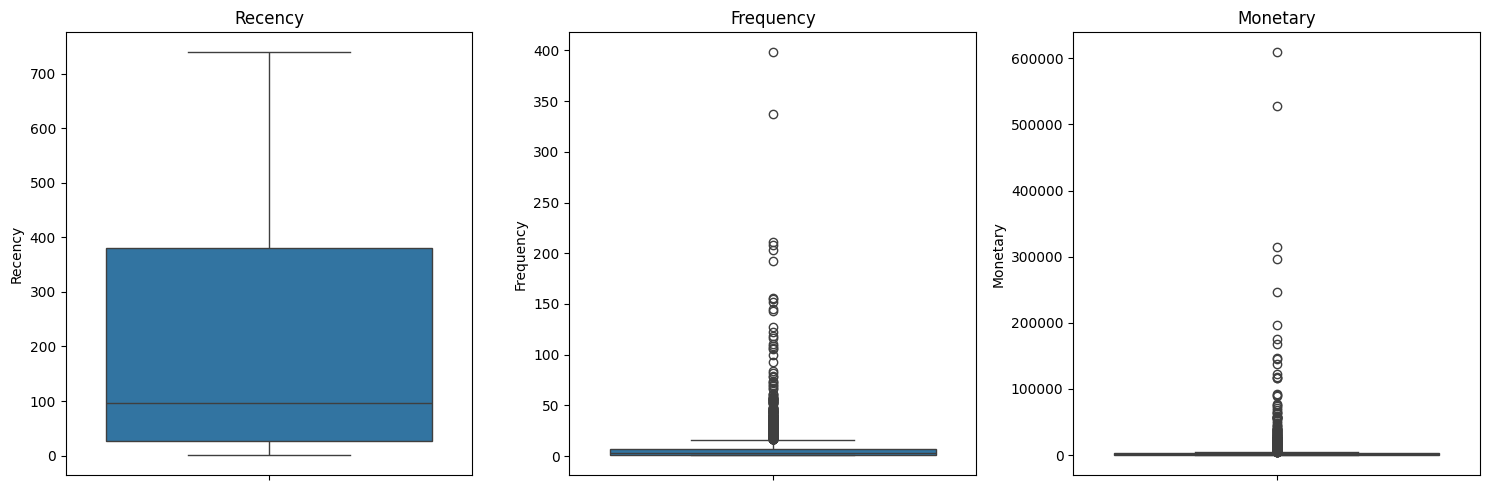

In [49]:
plt.figure(figsize=(15,5))
for i, column in enumerate(["Recency", "Frequency", "Monetary"], 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=rfm[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [50]:
for column in rfm.columns:

    Q1 = rfm[column].quantile(0.25)
    Q3 = rfm[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = rfm[(rfm[column] < lower) |
                   (rfm[column] > upper)]

    print(f"{column}")
    print("Number of Outliers:", len(outliers))
    print("-"*40)

Recency
Number of Outliers: 0
----------------------------------------
Frequency
Number of Outliers: 427
----------------------------------------
Monetary
Number of Outliers: 628
----------------------------------------


In [51]:
rfm.skew()

Recency       0.886792
Frequency    12.653997
Monetary     25.320187
dtype: float64

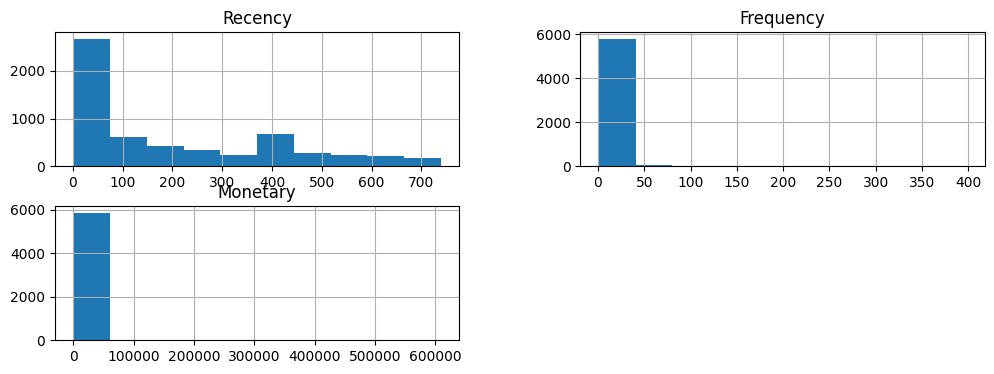

In [52]:
rfm.hist(figsize=(12,4))
plt.show()

In [53]:
rfm_log = rfm.copy()

In [54]:
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

In [55]:
rfm_log.skew()

Recency      0.886792
Frequency    1.001904
Monetary     0.207893
dtype: float64

In [56]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [57]:
rfm_log
rfm_log.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,2.564949,11.258774
12347.0,2,2.197225,8.636632
12348.0,75,1.791759,7.611051
12349.0,19,1.609438,8.396085
12350.0,310,0.693147,5.815324


# preprocessing

In [58]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_log_scaled = scaler.fit_transform(rfm_log)

In [59]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

In [60]:
rfm_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5881 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    5881 non-null   float64
 1   Frequency  5881 non-null   float64
 2   Monetary   5881 non-null   float64
dtypes: float64(3)
memory usage: 183.8 KB


In [61]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,5.881000e+03,5.881000e+03,5.881000e+03
mean,-4.953622e-17,-2.778861e-17,2.416401e-18
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-9.570384e-01,-4.063394e-01,-2.047853e-01
25%,-8.376818e-01,-4.063394e-01,-1.811783e-01
50%,-5.034832e-01,-2.526325e-01,-1.438590e-01
75%,8.524080e-01,5.478146e-02,-4.838817e-02
max,2.566369e+00,3.010449e+01,4.111923e+01


# modeling

## finding best K

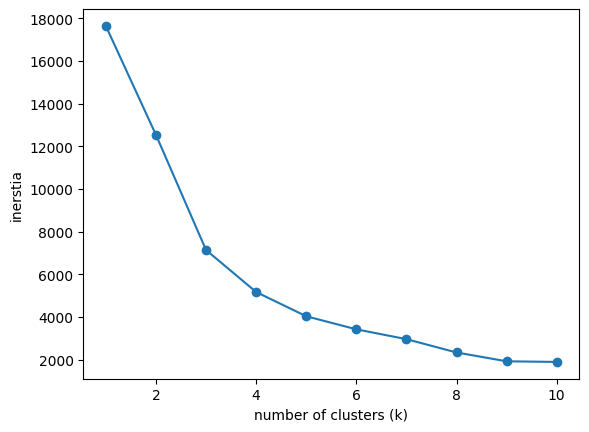

In [62]:
i = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(rfm_scaled)
    i.append(kmeans.inertia_)

plt.plot(range(1,11),i,marker='o')
plt.xlabel("number of clusters (k)")
plt.ylabel("inerstia")
plt.show()

# silhouette scores

In [63]:
log_scores = []
for lk in range(2,11):
    log_kmeans = KMeans(n_clusters=lk,random_state=42)
    log_labels = log_kmeans.fit_predict(rfm_log_scaled)
    log_score = silhouette_score(rfm_log_scaled,log_labels)
    log_scores.append(log_score)
    print(f"k: {lk} and score {log_score:.4f}")

k: 2 and score 0.4185
k: 3 and score 0.4009
k: 4 and score 0.3838
k: 5 and score 0.3659
k: 6 and score 0.3501
k: 7 and score 0.3352
k: 8 and score 0.3169
k: 9 and score 0.3123
k: 10 and score 0.3146


In [64]:
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled,labels)
    scores.append(score)
    print(f"k: {k} and score {score:.4f}")

k: 2 and score 0.5568
k: 3 and score 0.5828
k: 4 and score 0.5905
k: 5 and score 0.6078
k: 6 and score 0.5454
k: 7 and score 0.5489
k: 8 and score 0.5495
k: 9 and score 0.5091
k: 10 and score 0.4791


In [65]:
kmeans_model = KMeans(n_clusters=5,random_state=42)
kmean_rfm = rfm.copy()
kmean_rfm["clusters"] = kmeans_model.fit_predict(rfm_scaled)

In [66]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [67]:
kmean_rfm.head()

,Recency,Frequency,Monetary,clusters
Customer ID,,,,
12346.0,326,12,77556.46,4
12347.0,2,8,5633.32,0
12348.0,75,5,2019.40,0
12349.0,19,4,4428.69,0
12350.0,310,1,334.40,1


In [68]:
kmean_rfm.groupby("clusters").mean()

,Recency,Frequency,Monetary
clusters,,,
0,74.267201,5.405913,2036.372985
1,470.369103,2.159668,752.707016
2,27.764706,161.176471,137806.995294
3,1.500000,148.500000,568712.085000
4,26.060510,32.509554,17330.192430


In [69]:
kmean_rfm["clusters"].value_counts()

clusters
0    3619
1    1929
4     314
2      17
3       2
Name: count, dtype: int64

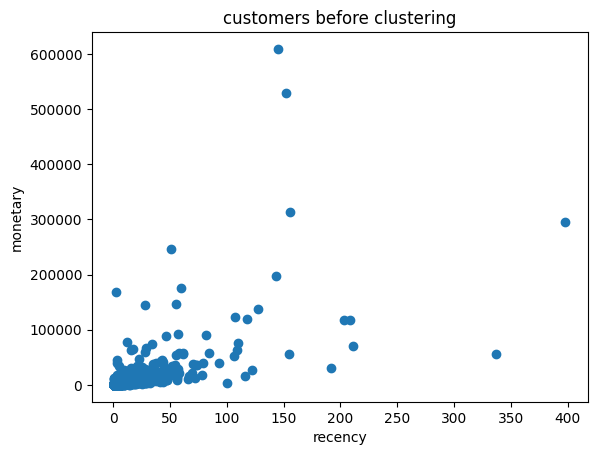

In [70]:
plt.scatter(kmean_rfm["Frequency"],kmean_rfm["Monetary"])
plt.title("customers before clustering")
plt.xlabel("recency")
plt.ylabel("monetary")
plt.show()

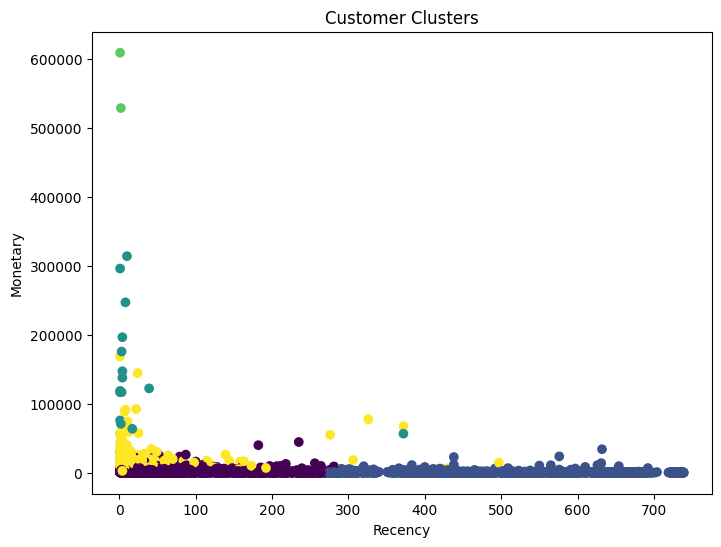

In [71]:
plt.figure(figsize=(8,6))

plt.scatter(
    kmean_rfm["Recency"],
    kmean_rfm["Monetary"],
    c=kmean_rfm["clusters"]
)

plt.title("Customer Clusters")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.show()

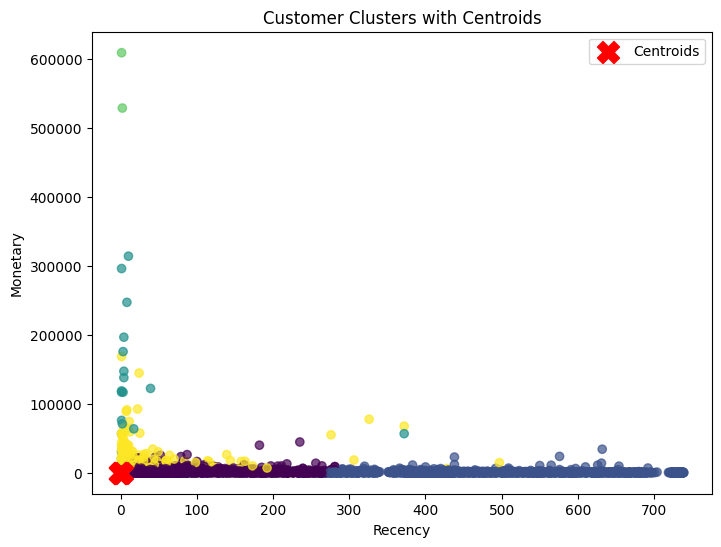

In [72]:
centroids = kmeans_model.cluster_centers_

plt.figure(figsize=(8,6))

plt.scatter(
    kmean_rfm["Recency"],
    kmean_rfm["Monetary"],
    c=kmean_rfm["clusters"],
    alpha=0.7
)

plt.scatter(
    centroids[:,0],
    centroids[:,2],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("Customer Clusters with Centroids")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.legend()

plt.show()

# Hierarchical clustering model

In [73]:
Z = linkage(
    rfm,
    method="ward"
)

In [74]:
# plt.figure(figsize=(19,9))

# dendrogram(Z)

# plt.title("Hierarchical Clustering Dendrogram")
# plt.xlabel("Customers")
# plt.ylabel("Distance")

# plt.show()

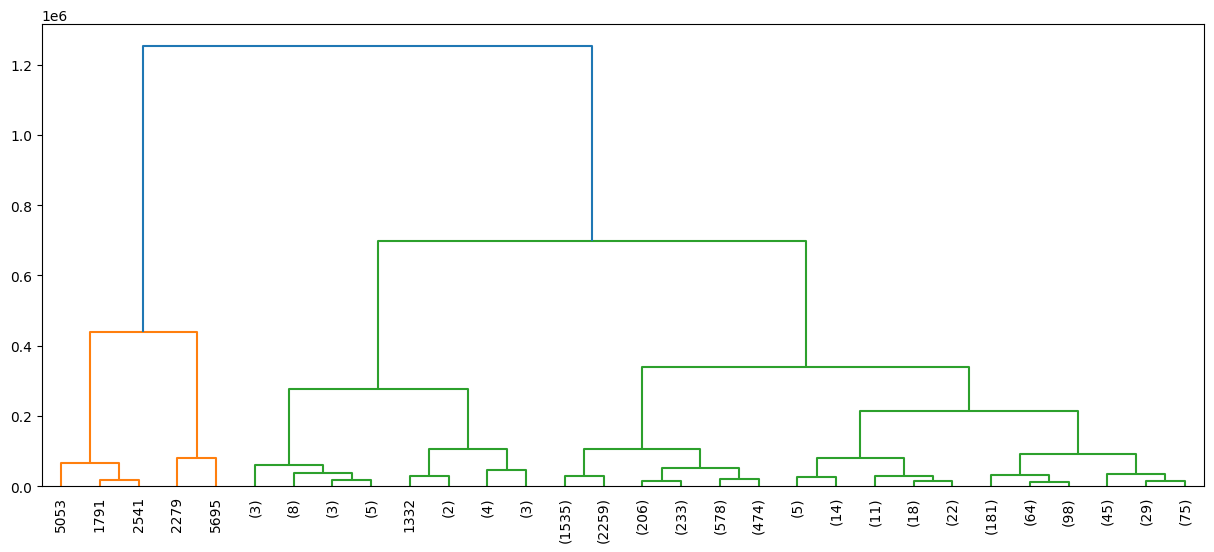

In [75]:
plt.figure(figsize=(15,6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.show()

In [76]:
from scipy.cluster.hierarchy import fcluster

labels = fcluster(Z, t=300000, criterion='distance')

print("Number of clusters:", len(set(labels)))

Number of clusters: 5


In [77]:
hc_model = AgglomerativeClustering(n_clusters=5,linkage="ward")
hc_scaled = AgglomerativeClustering(n_clusters=5,linkage="ward")
hc_log = AgglomerativeClustering(n_clusters=5,linkage="ward")
label = hc_model.fit_predict(rfm)
label2 = hc_scaled.fit_predict(rfm_scaled)
label3 = hc_log.fit_predict(rfm_log_scaled)

In [78]:
hc_rfm = rfm.copy()
hc_rfm["hc cluster"] = label

In [79]:
hc_rfm.head()

,Recency,Frequency,Monetary,hc cluster
Customer ID,,,,
12346.0,326,12,77556.46,0
12347.0,2,8,5633.32,2
12348.0,75,5,2019.40,1
12349.0,19,4,4428.69,1
12350.0,310,1,334.40,1


In [80]:
hc_score = silhouette_score(rfm,label)
hc_scaled_score = silhouette_score(rfm_scaled,label)
hc_log_scaled_score = silhouette_score(rfm_log_scaled,label)
print("score:",hc_score)
print("score:",hc_scaled_score)
print("score:",hc_log_scaled_score)

score: 0.8040556525087168
score: 0.38691924768597497
score: 0.32657935022572154


In [81]:
hc_rfm["hc cluster"].value_counts()

hc cluster
1    5285
2     562
0      29
3       3
4       2
Name: count, dtype: int64

In [82]:
hc_rfm.groupby("hc cluster").mean()

,Recency,Frequency,Monetary
hc cluster,,,
0,53.655172,90.103448,94181.980000
1,218.150237,3.969915,1202.710710
2,53.862989,22.204626,11853.219568
3,6.333333,201.666667,285630.696667
4,1.500000,148.500000,568712.085000


In [83]:
kmean_rfm.groupby("clusters").mean()

,Recency,Frequency,Monetary
clusters,,,
0,74.267201,5.405913,2036.372985
1,470.369103,2.159668,752.707016
2,27.764706,161.176471,137806.995294
3,1.500000,148.500000,568712.085000
4,26.060510,32.509554,17330.192430


# DBSCAN

In [116]:
dbscan1 = DBSCAN(eps=0.7,
                min_samples=3)

In [117]:
dbscan2 = DBSCAN(eps=0.5,
                min_samples=3)

In [118]:
db_labels1 = dbscan1.fit_predict(rfm_scaled)

In [119]:
db_labels2 = dbscan2.fit_predict(rfm_scaled)

In [120]:
dbscan_rfm1 = rfm.copy()
dbscan_rfm1["dbscan cluster"] = db_labels1

In [121]:
dbscan_rfm2 = rfm.copy()
dbscan_rfm2["dbscan cluster"] = db_labels2

In [122]:
dbscan_rfm1["dbscan cluster"].value_counts().sort_index()

dbscan cluster
-1      45
 0    5824
 1       4
 2       5
 3       3
Name: count, dtype: int64

In [123]:
dbscan_rfm2["dbscan cluster"].value_counts().sort_index()

dbscan cluster
-1      48
 0    5817
 1       4
 2       4
 3       3
 4       5
Name: count, dtype: int64

In [124]:
dbscan_rfm1.groupby("dbscan cluster")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
dbscan cluster,,,
-1,101.866667,93.844444,110159.854489
0,202.628091,5.481456,2126.676813
1,3.500000,74.000000,37421.240000
2,8.400000,70.400000,15933.828000
3,9.000000,60.000000,57038.623333


In [125]:
dbscan_rfm2.groupby("dbscan cluster")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
dbscan cluster,,,
-1,104.895833,90.833333,104202.445458
0,202.794568,5.443184,2088.942072
1,3.500000,74.000000,37421.240000
2,4.500000,68.500000,15337.432500
3,9.000000,60.000000,57038.623333
4,4.600000,40.400000,41637.040200


In [126]:
db_clusters = len(set(db_labels1)) - (1 if -1 in db_labels1 else 0)

print("Clusters:", db_clusters)

print("Noise Points:", list(db_labels1).count(-1))

Clusters: 4
Noise Points: 45


In [127]:
for eps in [0.3, 0.5, 0.7, 1.0, 1.2, 1.5]:
    for ms in [3, 5, 10]:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(rfm_scaled)

        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = (labels == -1).sum()

        print(
            f"eps={eps}, min_samples={ms} "
            f"Clusters={clusters}, Noise={noise}"
        )

eps=0.3, min_samples=3 Clusters=11, Noise=75
eps=0.3, min_samples=5 Clusters=2, Noise=123
eps=0.3, min_samples=10 Clusters=1, Noise=158
eps=0.5, min_samples=3 Clusters=5, Noise=48
eps=0.5, min_samples=5 Clusters=1, Noise=65
eps=0.5, min_samples=10 Clusters=1, Noise=82
eps=0.7, min_samples=3 Clusters=4, Noise=45
eps=0.7, min_samples=5 Clusters=2, Noise=52
eps=0.7, min_samples=10 Clusters=1, Noise=60
eps=1.0, min_samples=3 Clusters=4, Noise=37
eps=1.0, min_samples=5 Clusters=1, Noise=50
eps=1.0, min_samples=10 Clusters=1, Noise=50
eps=1.2, min_samples=3 Clusters=3, Noise=33
eps=1.2, min_samples=5 Clusters=1, Noise=40
eps=1.2, min_samples=10 Clusters=1, Noise=46
eps=1.5, min_samples=3 Clusters=2, Noise=22
eps=1.5, min_samples=5 Clusters=1, Noise=30
eps=1.5, min_samples=10 Clusters=1, Noise=35


In [128]:
if len(set(db_labels1)) > 1:
    score = silhouette_score(rfm_scaled, db_labels1)
    print("Silhouette Score:", round(score,3))
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score: 0.723


In [129]:
if len(set(db_labels2)) > 1:
    score = silhouette_score(rfm_scaled, db_labels2)
    print("Silhouette Score:", round(score,3))
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score: 0.644


In [104]:
kmean_rfm["clusters"].value_counts().sort_index()

clusters
0    3619
1    1929
2      17
3       2
4     314
Name: count, dtype: int64

In [99]:
kmean_rfm.groupby("clusters")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
clusters,,,
0,74.267201,5.405913,2036.372985
1,470.369103,2.159668,752.707016
2,27.764706,161.176471,137806.995294
3,1.500000,148.500000,568712.085000
4,26.060510,32.509554,17330.192430


In [100]:
0.60

0.6

In [103]:
hc_rfm["hc cluster"].value_counts().sort_index()

hc cluster
0      29
1    5285
2     562
3       3
4       2
Name: count, dtype: int64

In [105]:
hc_rfm.groupby("hc cluster")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
hc cluster,,,
0,53.655172,90.103448,94181.980000
1,218.150237,3.969915,1202.710710
2,53.862989,22.204626,11853.219568
3,6.333333,201.666667,285630.696667
4,1.500000,148.500000,568712.085000


In [106]:
0.80
0.38
0.32

0.32

In [131]:
dbscan_rfm1["dbscan cluster"].value_counts().sort_index()

dbscan cluster
-1      45
 0    5824
 1       4
 2       5
 3       3
Name: count, dtype: int64

In [132]:
dbscan_rfm1.groupby("dbscan cluster")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
dbscan cluster,,,
-1,101.866667,93.844444,110159.854489
0,202.628091,5.481456,2126.676813
1,3.500000,74.000000,37421.240000
2,8.400000,70.400000,15933.828000
3,9.000000,60.000000,57038.623333
